In [1]:
import sys
import pickle
from pathlib import Path

import pandas as pd
import geopandas as gpd 
import numpy as np
import matplotlib as mp
import matplotlib.pyplot as plt

import config, data, models, train, evaluate

In [5]:
proj_root = Path("/nas/cee-water/cjgleason/ted/swot-ml")
data_dir = proj_root / 'data' / 'reservoirs' 
metadata_dir = data_dir / 'metadata'
basins = gpd.read_parquet(metadata_dir / "All_MERIT_matchups.parquet").set_index('comid')
basins.index = basins.index.astype(str)

In [37]:
swot_subs = basins.dropna(subset=['reach_id', 'provider'])
swot_subs = swot_subs[swot_subs['mean_discharge']>10]

swot_subs = swot_subs.index.to_list()
len(swot_subs)

1881

In [41]:
exp_root = Path("/nas/cee-water/cjgleason/ted/swot-ml/runs/cache_short_spq")
exp_dirs = [p.parent for p in (exp_root).rglob('results/test_results.parquet')] # dirs with test_data.pkl

# exp_dirs = [exp_dirs[i] for i in [-1, 0, 2, 1, -2]]
# exp_dirs = [exp_dirs[i] for i in [3, 2, 1]]

fig_dir = exp_root / "_figures"
fig_dir.mkdir(exist_ok=True, parents=True)

def q2Q(time_series, basins):
    for level0_name in ['obs','pred']:
        # Define the source and target column tuples
        source_col = (level0_name, 'sp_discharge')
        target_col = (level0_name, 'discharge')
    
        # Perform the multiplication aligning on the 'basin' index level
        time_series[target_col] = time_series[source_col].mul(
            basins['total_area'], 
            level='subbasin'
        )
    return time_series

exps = []
for exp_dir in exp_dirs:
    exp_name = '+'.join(exp_dir.parent.stem.split('_')[:-2]) 
    print(exp_name)

    results = pd.read_parquet(exp_dir / 'test_results.parquet').dropna()
    swot_mask = results.index.get_level_values('subbasin').isin(swot_subs)
    results = results[swot_mask]
    
    results = q2Q(results.droplevel(0,0), basins)
    
    bulk_m = evaluate.get_all_metrics(results)
    basin_m = evaluate.get_basin_metrics(results)

    exps.append((exp_name, results, bulk_m, basin_m))

exps = sorted(exps, key=lambda x: x[0])

era5+swot
era5


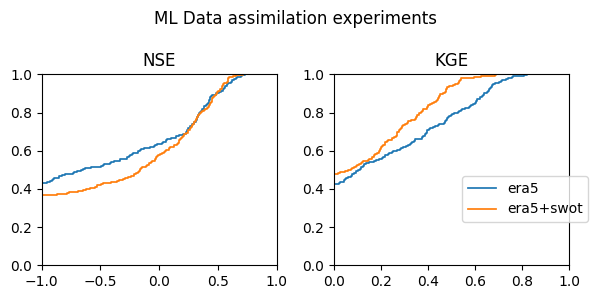

In [44]:
plt.close('all')

num_models = len(exps)

metric_names = {'NSE': 'NSE',
                'KGE': 'KGE'}

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes = axes.flatten()

for ax, (name, title) in zip(axes, metric_names.items()):
    for exp_name, results, bulk_metrics, basin_metrics in exps:
        x = np.array(basin_metrics['discharge'][name], dtype=float)
        x = x[~np.isnan(x)]
        ax.ecdf(x, linewidth=1.25, label=exp_name)
    
    ax.set_title(title)

axes[0].set_xlim([-1, 1])
axes[1].set_xlim([0, 1])

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.0, 0.35))

# fig.subplots_adjust(left=0.1, right=0.95, bottom=0.2, top=0.95, wspace=0.3, hspace=0.4)
plt.suptitle('ML Data assimilation experiments')
plt.tight_layout()
plt.show()

# fig.savefig(fig_dir / f"ABC_cdfs.png", dpi=300)

In [37]:
exps[1][3]['discharge']

Metric,num_obs,R2,MAPE,nBias,RE,RB,qRE,qnBias,MAE,RMSE,rRMSE,KGE,NSE,Agreement
74024610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74024620,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74024945,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74025163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74025192,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USGS-03601990,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
USGS-03603000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
USGS-03604000,1728,0.443531,40.951134,-19.45878,41.497576,-24.160026,"[18.28689611777168, 41.497576127723846, 90.226...","[-40.16883753804293, -19.458779566400622, 10.7...",9.478732,25.600783,129.690161,0.508235,0.443531,0.613096
USGS-03604400,1728,0.470513,34.52627,-18.16584,36.28015,-22.198359,"[16.425398813656166, 36.28014970209335, 65.496...","[-34.643364413060795, -18.16584017268814, 5.69...",13.828274,36.799065,115.950112,0.510546,0.470513,0.626571


In [ ]:
results['obs']['discharge'].groupby('basin').mean().dropna().sort_values()

In [ ]:
basin_metrics['discharge']['NSE'].dropna().sort_values()

metric='NSE'
e5: 0.41
e5_swot_s2: 0.41


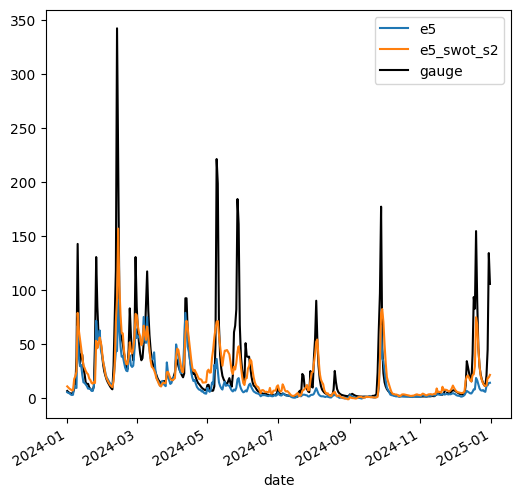

In [51]:
reach_id = 'USGS-03281500'
start_date = "2024-01-01"
end_date = "2025-01-01"
metric = 'NSE'
print(f"{metric=}")

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for exp_name, results, bulk_metrics, basin_metrics in exps: 
    x = results.xs(reach_id, level='basin').sort_index()
    x = x.loc[start_date:end_date]
    x['pred']['discharge'].plot(ax=ax, label=exp_name)
    print(f"{exp_name}: {basin_metrics.loc[reach_id]['discharge'][metric]:0.2f}")
    
x['obs']['discharge'].plot(color='black', ax=ax, label='gauge', zorder=0)
plt.legend()

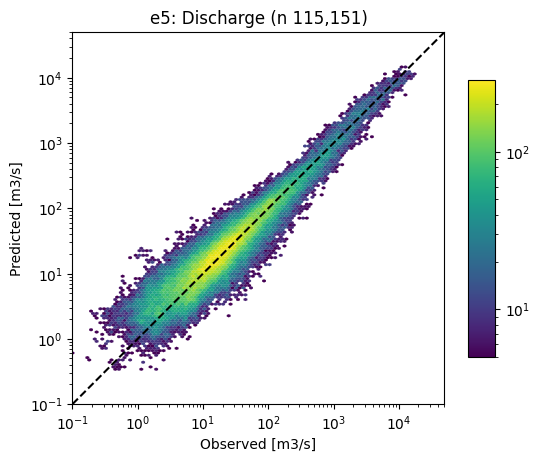

In [52]:
fig, ax = plt.subplots(1, 1, figsize=(6, 6))

exp_idx = 0
name = exps[exp_idx][0]

x = exps[exp_idx][1]['obs']['discharge']
y = exps[exp_idx][1]['pred']['discharge']
positive_mask = (x > 0) & (y > 0)
x = x[positive_mask]
y = y[positive_mask]

min_val = 1E-1
max_val = 5E4
log_min = np.log10(min_val)
log_max = np.log10(max_val)

hb = ax.hexbin(x, y, gridsize=(100,80), bins='log', mincnt=5,
            linewidth=0.1,
            extent=(log_min, log_max, log_min, log_max),
            xscale='log', yscale='log')
plt.colorbar(hb, shrink=0.6, aspect=10, anchor=(0,0.5))

# Add a 1:1 line over the min and max of x and y
ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=1.5)

# Setting axes to be square and equal range
ax.axis('square')
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.set_title(f"{name}: Discharge (n {len(x):,})")
ax.set_xlabel(f'Observed [m3/s]')
ax.set_ylabel(f'Predicted [m3/s]')
plt.show()

fig.savefig(fig_dir / f"{name}_bulk_scatterplots.png", dpi=300)